In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sb
import scrublet as scr
plt.rcParams["figure.figsize"] = (6, 5)

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 3
sc.logging.print_version_and_date()

Running Scanpy 1.6.1, on 2021-01-29 14:43.


In [2]:
def timestamp():
    import datetime, time
    ts = time.time()
    st = datetime.datetime.fromtimestamp(ts).strftime('%d-%m-%Y %H:%M:%S')
    return st

def mysize(w, h, d):
    fig, ax = plt.subplots(figsize = (w, h), dpi = d)
    return(fig.gca())

from matplotlib import colors
mymap = colors.LinearSegmentedColormap.from_list('my_colormap', np.vstack([plt.cm.Reds(np.linspace(0, 1, 128)),
                                                  plt.cm.Greys_r(np.linspace(0.7, 0.8, 0))]))
gray_red = colors.LinearSegmentedColormap.from_list("grouping", ["lightgray", "red", "darkred"], N = 128)

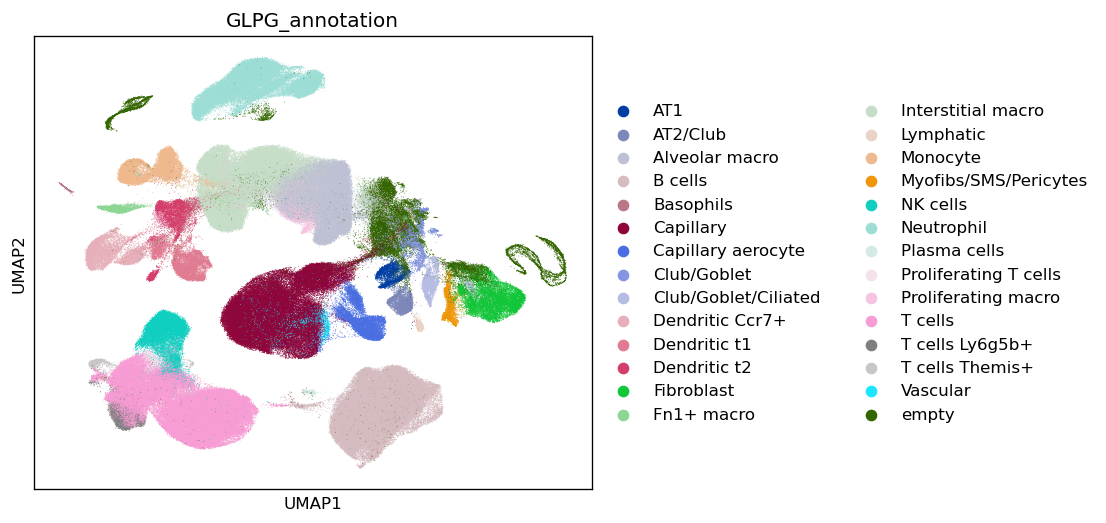

In [5]:
folder = "/storage/groups/ml01/workspace/meshal.ansari/PhD_Scripts/GLPG/"

adata = sc.read(folder + "210119_GLPG_souped.h5ad")
sc.pl.umap(adata, color = ["GLPG_annotation"], size = 1, ax = mysize(6, 5, 120))

In [4]:
print(type(adata.layers["counts"]))
adata

<class 'scipy.sparse.csr.csr_matrix'>


AnnData object with n_obs × n_vars = 517376 × 27868
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'GLPG_annotation'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'GLPG_annotation_colors', 'cluster_03_colors', 'condition_colors', 'hvg', 'identifier_colors', 'louvain', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivities', 'distances'

### Sample wise Doublet Detection

In [6]:
## Preparations
ids = adata.obs.identifier.cat.categories
#adata.obs["size_factors"] = np.nan
adata.obs["doublet_scores"] = np.nan

In [9]:
for i, cur_id in enumerate(ids):
    sub = adata[adata.obs.identifier == cur_id].copy()

    # Doublet Detection
    ## Input: raw (unnormalized) UMI counts matrix counts_matrix with cells as rows and genes as columns
    print("%s\tCalculating doublet score for %s\t%s" %(i, cur_id, timestamp()))
    scrub = scr.Scrublet(sub.layers["unsouped_counts"])
    doublet_scores, predicted_doublets = scrub.scrub_doublets(verbose = False)
    doublet_scores = pd.DataFrame(doublet_scores, index = sub.obs_names, columns = ["doublet_scores"])
    adata.obs["doublet_scores"].update(doublet_scores.doublet_scores)
    

0	Calculating doublet score for d10BLM9	29-01-2021 11:44:47
1	Calculating doublet score for d10BLM10	29-01-2021 11:44:52
2	Calculating doublet score for d10BLM11	29-01-2021 11:44:55
3	Calculating doublet score for d10BLM12	29-01-2021 11:45:03
4	Calculating doublet score for d10BLM13	29-01-2021 11:45:10
5	Calculating doublet score for d10BLM14	29-01-2021 11:45:21
6	Calculating doublet score for d10BLM15	29-01-2021 11:45:27
7	Calculating doublet score for d10BLM16	29-01-2021 11:45:36
8	Calculating doublet score for d10BLM_Combo39	29-01-2021 11:45:44
9	Calculating doublet score for d10BLM_Combo41	29-01-2021 11:45:47
10	Calculating doublet score for d10BLM_Combo42	29-01-2021 11:45:59
11	Calculating doublet score for d10BLM_Combo43	29-01-2021 11:46:04
12	Calculating doublet score for d10BLM_Combo44	29-01-2021 11:46:23
13	Calculating doublet score for d10BLM_Combo46	29-01-2021 11:46:39
14	Calculating doublet score for d10BLM_Combo47	29-01-2021 11:46:43
15	Calculating doublet score for d10BLM

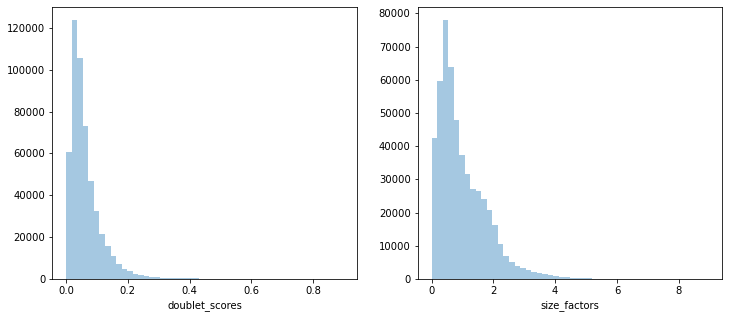

In [10]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))
axs = axs.ravel()

sb.distplot(adata.obs["doublet_scores"], kde = False, ax = axs[0])
sb.distplot(adata.obs["size_factors"], kde = False, ax = axs[1])
plt.show()

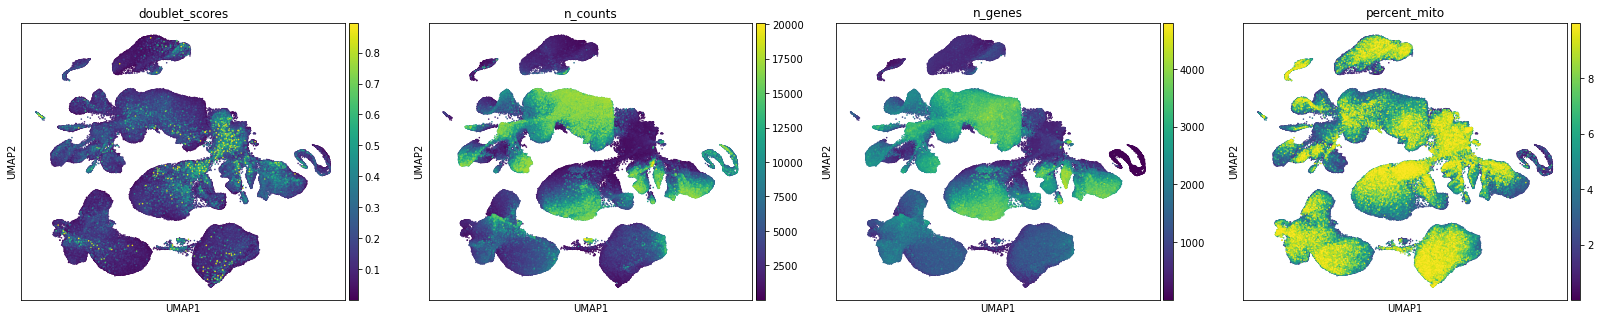

In [58]:
sc.pl.umap(adata, color = ["doublet_scores", "n_counts", "n_genes", "percent_mito"], size = 10)

In [11]:
## Save doublet scores already in object (overwrite previous)
folder = "/storage/groups/ml01/workspace/meshal.ansari/PhD_Scripts/GLPG/"
adata.write(folder + "210119_GLPG_souped.h5ad")

### Quality control - plot QC Metrics

In [54]:
folder = "/storage/groups/ml01/workspace/meshal.ansari/PhD_Scripts/GLPG/"
adata = sc.read(folder + "210119_GLPG_souped.h5ad")

In [56]:
## Recalculate Metrics (on souped layer)
adata.obs["n_counts"] = adata.layers["counts"].sum(1)         # sums over rows = cells
adata.obs["n_genes"] = (adata.layers["counts"] > 0).sum(1)

## Memory Error for percent Mito, so leave it

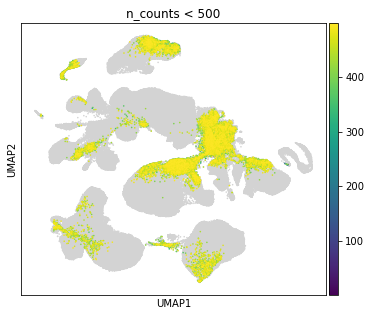

In [47]:
fig, axs = plt.subplots(figsize = (6, 5))
sc.pl.umap(adata, show = False, ax = axs, size = 10)
sc.pl.umap(adata[adata.obs.n_counts < 500], color = "n_counts", title = "n_counts < 500",
           size = 10, show = False, ax = axs)
plt.show()

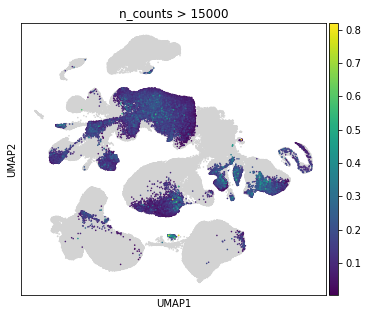

In [42]:
fig, axs = plt.subplots(figsize = (6, 5))
sc.pl.umap(adata, show = False, ax = axs, size = 10)
sc.pl.umap(adata[adata.obs.n_counts > 10000], color = "doublet_scores", title = "n_counts > 15000",
           size = 10, show = False, ax = axs)
plt.show()

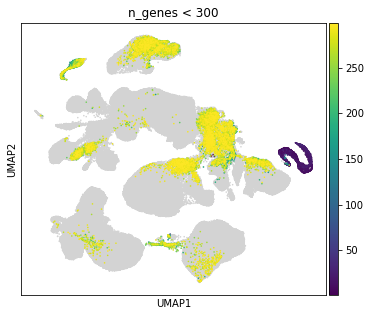

In [65]:
## better
fig, axs = plt.subplots(figsize = (6, 5))
sc.pl.umap(adata, show = False, ax = axs, size = 10)
sc.pl.umap(adata[adata.obs.n_genes < 300], color = "n_genes", title = "n_genes < 300",
           size = 10, show = False, ax = axs)
plt.show()

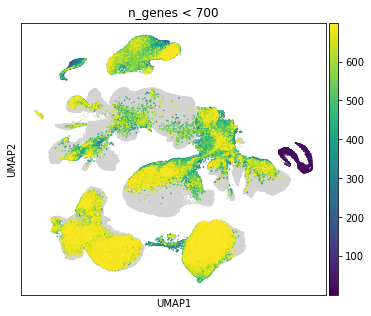

In [59]:
## Nah that’s too much
fig, axs = plt.subplots(figsize = (6, 5))
sc.pl.umap(adata, show = False, ax = axs, size = 10)
sc.pl.umap(adata[adata.obs.n_genes < 700], color = "n_genes", title = "n_genes < 700",
           size = 10, show = False, ax = axs)
plt.show()

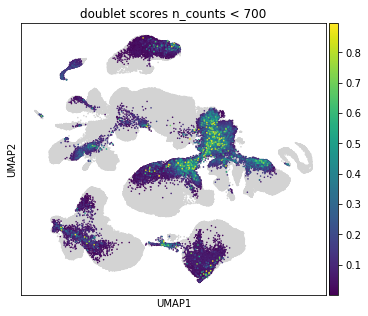

In [67]:
fig, axs = plt.subplots(figsize = (6, 5))
sc.pl.umap(adata, show = False, ax = axs, size = 10)
sc.pl.umap(adata[adata.obs.n_counts < 700], color = "doublet_scores", title = "doublet scores n_counts < 700",
           size = 10, show = False, ax = axs)
plt.show()

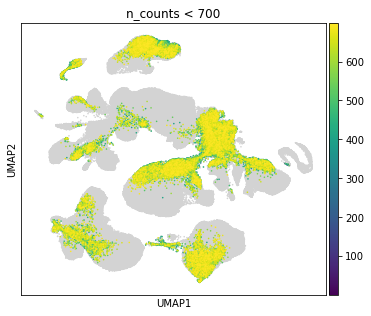

In [66]:
fig, axs = plt.subplots(figsize = (6, 5))
sc.pl.umap(adata, show = False, ax = axs, size = 10)
sc.pl.umap(adata[adata.obs.n_counts < 700], color = "n_counts", title = "n_counts < 700",
           size = 10, show = False, ax = axs)
plt.show()

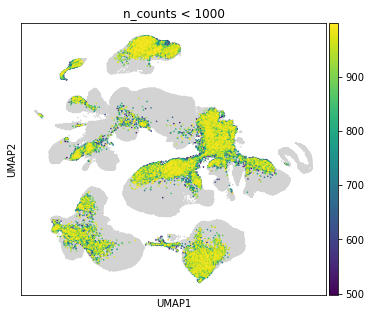

In [16]:
## Before recalculating n_counts on souped
# fig, axs = plt.subplots(figsize = (6, 5))
# sc.pl.umap(adata, show = False, ax = axs, size = 10)
# sc.pl.umap(adata[adata.obs.n_counts < 1000], color = "n_counts", title = "n_counts < 1000",
#            size = 10, show = False, ax = axs)
# plt.show()

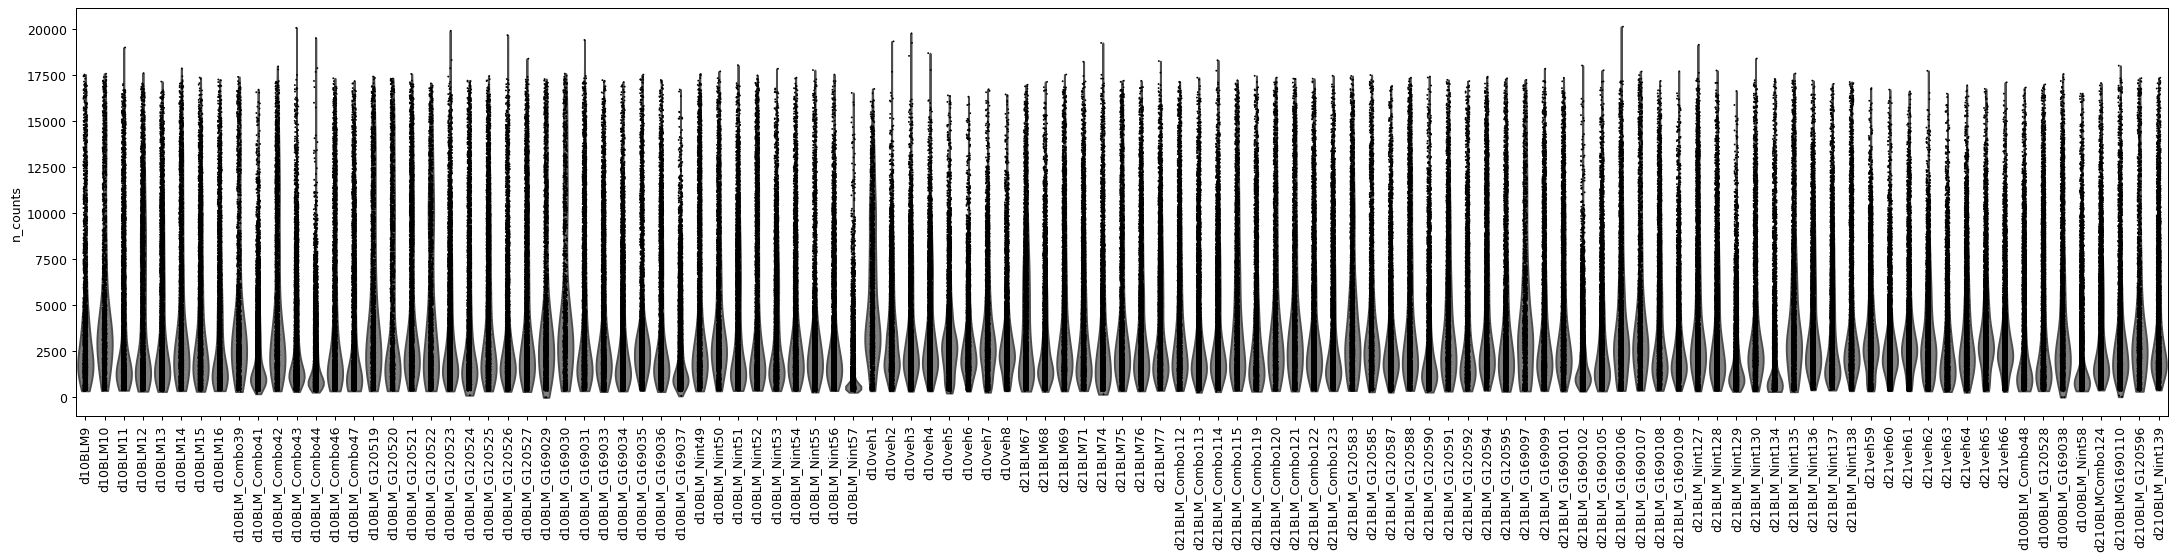

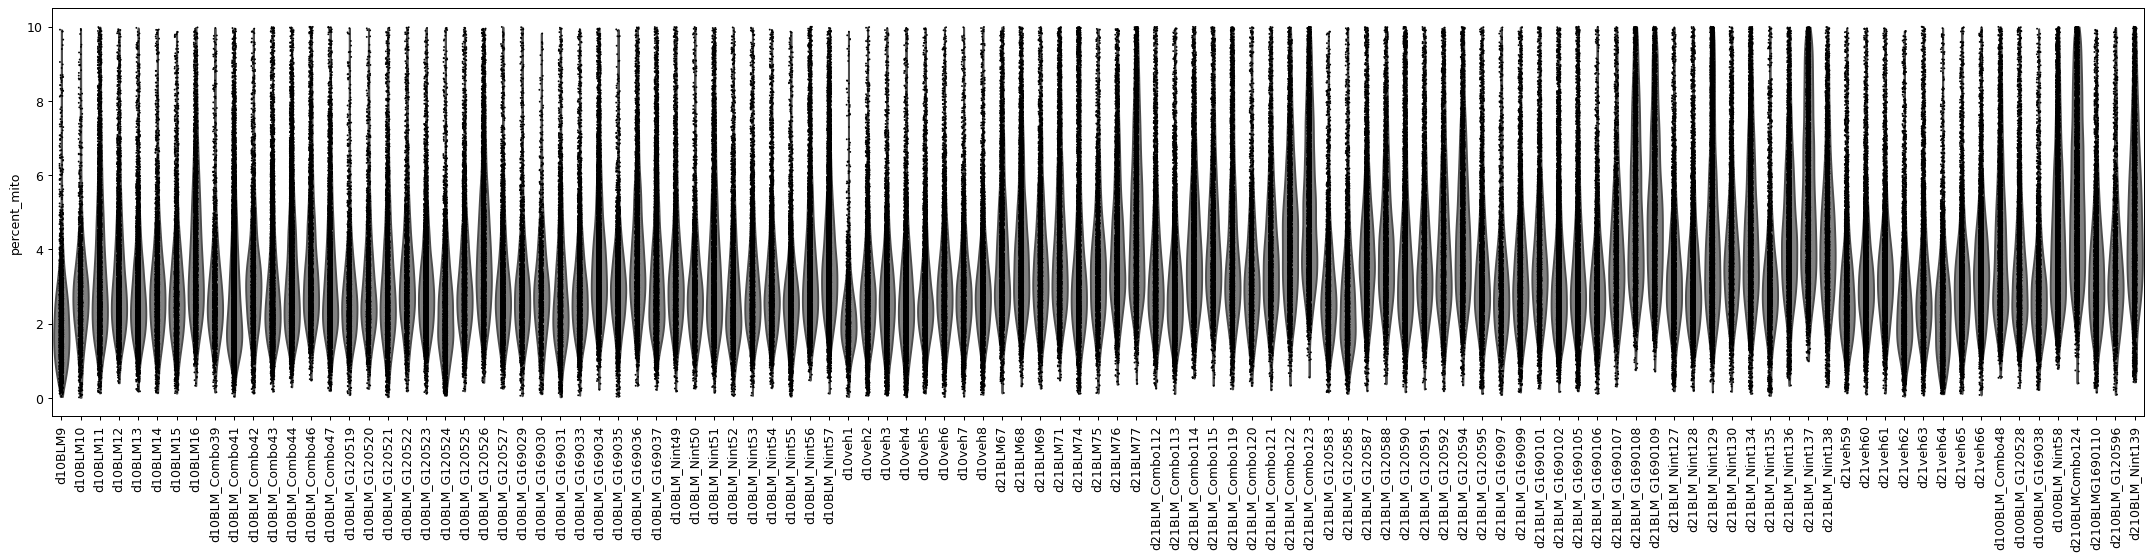

In [27]:
group = "identifier"
sc.pl.violin(adata, "n_counts", groupby = group, size = 1.5, ax = mysize(30, 6, 90), rotation = 90)
sc.pl.violin(adata, "percent_mito", groupby = group, size = 1.5, ax = mysize(30, 6, 90), rotation = 90)

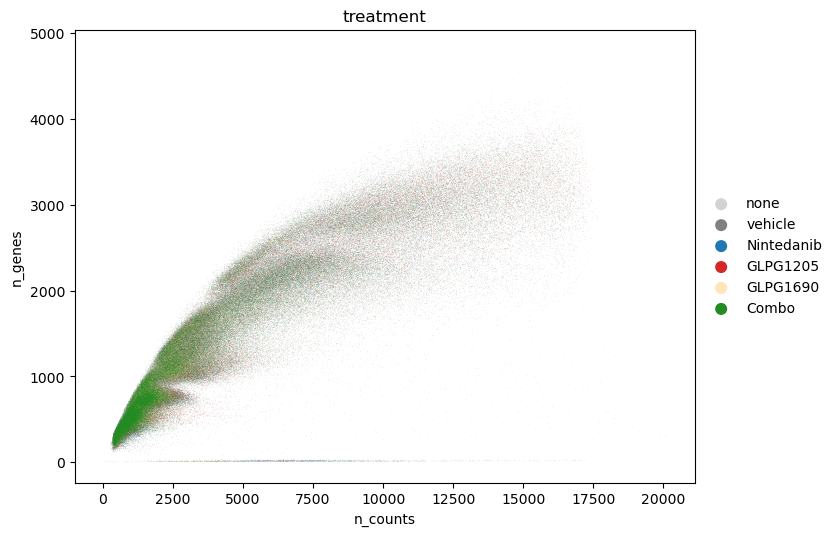

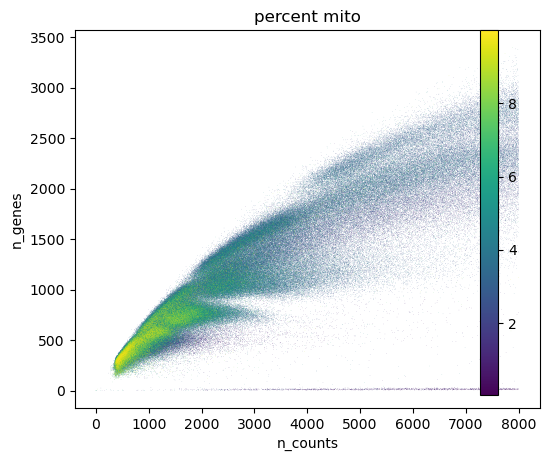

In [30]:
## Data quality summary plots
sc.pl.scatter(adata, "n_counts", "n_genes", color = "treatment", ax = mysize(8, 6, 100))

## Zoom in to range
sc.pl.scatter(adata[adata.obs["n_counts"] < 8000], "n_counts", "n_genes",
              ax = mysize(6,5,100), color = "percent_mito")

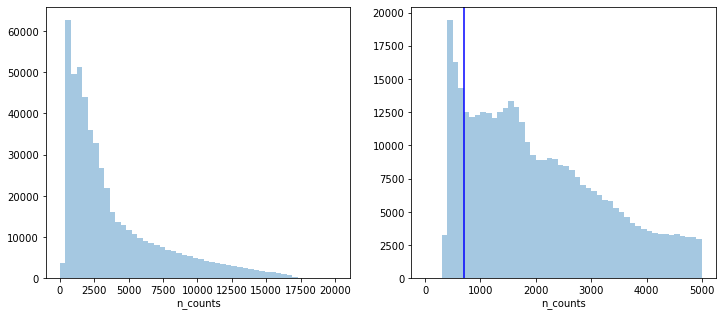

In [48]:
## Mostly similar to what we had in Version 1
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))
axs = axs.ravel()

sb.distplot(adata.obs["n_counts"], kde = False, ax = axs[0])
sb.distplot(adata.obs['n_counts'][adata.obs['n_counts'] < 5000], kde = False, ax = axs[1])
plt.axvline(700, color = "blue")
plt.show()

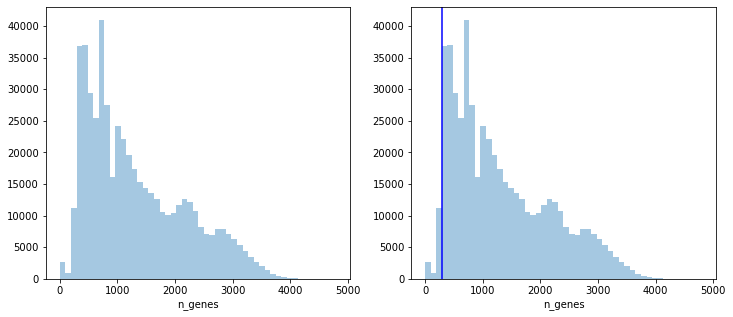

In [63]:
## Mostly similar to what we had in Version 1
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))
axs = axs.ravel()

sb.distplot(adata.obs["n_genes"], kde = False, ax = axs[0])
sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 5000], kde = False, ax = axs[1])
plt.axvline(300, color = "blue")
plt.show()

### Actually do the Filtering for remaining QC Parameters

In [68]:
## Do the filtering based on obs as .X already has log-normalized data
print('Total number of cells: {:d}'.format(adata.n_obs))

## Not doing an upper threshold here
#sc.pp.filter_cells(adata, max_counts = 50000)
#print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

## min_counts = 500 already considered, but you can increase the value if desired here
#sc.pp.filter_cells(adata, min_counts = 700)
adata = adata[adata.obs.n_counts > 700]
print('Number of cells after min n_count filter: {:d}'.format(adata.n_obs))

#sc.pp.filter_cells(adata, min_genes = 700)
adata = adata[adata.obs.n_genes > 300]
print('Number of cells after min n_genes filter: {:d}'.format(adata.n_obs))

sc.pp.filter_genes(adata, min_cells = 5)
print('Number of cells after gene filter: {:d}'.format(adata.n_obs))

## No percent Mito filter as < 0.1 already considered by GLPG

Total number of cells: 517376
Number of cells after min n_count filter: 464032
Number of cells after min n_genes filter: 459907
filtered out 1727 genes that are detected in less than 5 cells


Trying to set attribute `.var` of view, copying.


Number of cells after gene filter: 459907


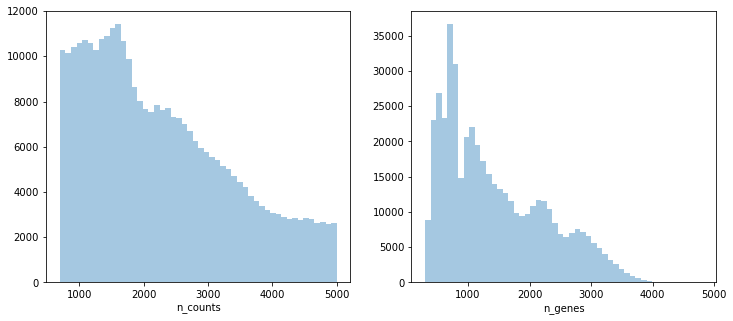

In [69]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))
axs = axs.ravel()

sb.distplot(adata.obs["n_counts"][adata.obs['n_counts'] < 5000], kde = False, ax = axs[0])
sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 5000], kde = False, ax = axs[1])
plt.show()

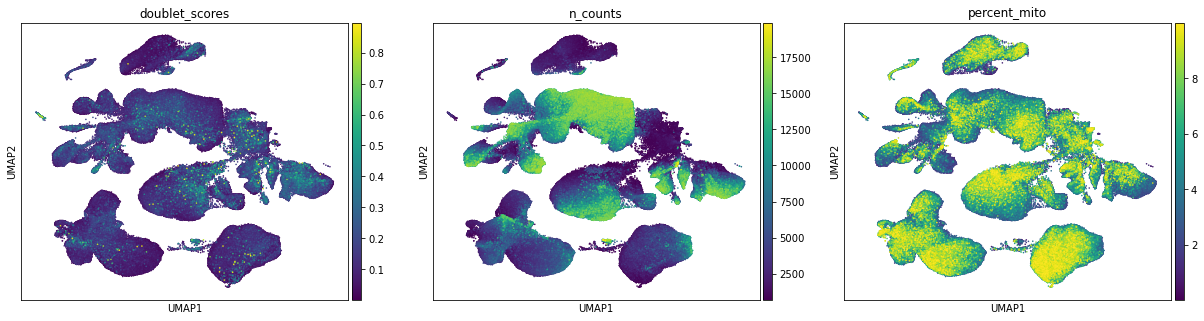

In [70]:
sc.pl.umap(adata, color = ["doublet_scores", "n_counts", "percent_mito"], size = 10)

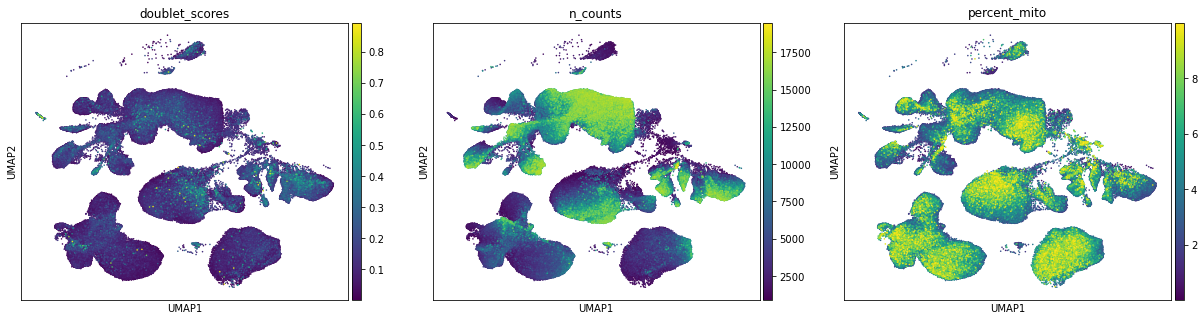

In [52]:
## with min_genes = 700, a bit to many removed
#  sc.pl.umap(adata, color = ["doublet_scores", "n_counts", "percent_mito"], size = 10)

In [72]:
## Do not re-normalize
print("unsouped counts\n", type(adata.layers["unsouped_counts"]), "\n",
      adata.layers["unsouped_counts"][:5, :10].todense(), "\n")
print("souped counts\n", type(adata.layers["counts"]), "\n", adata.layers["counts"][:5, :10].todense(), "\n")
print("log-normed counts in .X\n", type(adata.X), "\n", adata.X[:5, :10].todense(), "\n")

unsouped counts
 <class 'anndata._core.views.SparseCSRView'> 
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 2. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 2.]] 

souped counts
 <class 'anndata._core.views.SparseCSRView'> 
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 2.]] 

log-normed counts in .X
 <class 'scipy.sparse.csr.csr_matrix'> 
 [[0.        0.        0.        0.        0.        0.        0.
  0.        0.        0.9164747]
 [0.        0.        0.        0.        0.        0.        0.4729996
  0.        0.        0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.        0.        0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.        0.        0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.       

In [71]:
## Save this filtered object (do not overwrite previous)
folder = "/storage/groups/ml01/workspace/meshal.ansari/PhD_Scripts/GLPG/"
adata.write(folder + "210129_GLPG_souped_filtered.h5ad")

### Selection of highly Variable Genes (consider in how many Samples they are variable)

extracting highly variable genes
    finished (0:00:29)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


<AxesSubplot:>

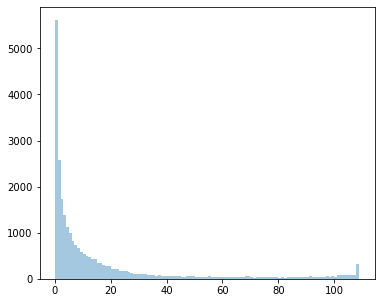

In [73]:
batch = "identifier"
sc.pp.highly_variable_genes(adata, min_disp = None, max_disp = None, min_mean = None, max_mean = None, 
                                batch_key = batch, n_top_genes = 4000, n_bins = 20, flavor = "cell_ranger", 
                                subset = False)
vartab = pd.DataFrame(adata.var["highly_variable_nbatches"], index = adata.var_names)
sb.distplot(vartab, kde = False, bins = len(np.unique(adata.obs[batch])))

In [74]:
thresh = 10
hvgs = vartab[vartab.highly_variable_nbatches.values >= thresh].index
print("%s Genes kept, variable in at least %s samples" %(len(hvgs), thresh))

9878 Genes kept, variable in at least 10 samples


### Remove Cell cycle Genes from list of variable genes

In [76]:
## Remove cell cycle genes from list - Mouse
cc_genes = [x.strip().capitalize() for x in open("/storage/groups/ml01/workspace/meshal.ansari/PhD_Scripts/" +
                                                 "Meta_Analysis/regev_lab_cell_cycle_genes.txt")]
hvgs = np.setdiff1d(hvgs, cc_genes)

In [77]:
adata.var["highly_variable"] = [g in hvgs for g in adata.var_names]
sum(adata.var["highly_variable"])

9825

### Calculate cell cycle Score (but skip Regression because of Memory Issues)

In [78]:
s_genes = cc_genes[:43]
g2m_genes = cc_genes[43:]
cc_genes = np.intersect1d(adata.var_names, cc_genes)
sc.tl.score_genes_cell_cycle(adata, s_genes = s_genes, g2m_genes = g2m_genes)

calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    469 total control genes are used. (0:00:24)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    602 total control genes are used. (0:00:23)
-->     'phase', cell cycle phase (adata.obs)


### Visualizations

In [79]:
## Mapped on top based on Emiel’s meta data
display(adata.obs.time_point.value_counts().reset_index())
display(adata.obs.treatment.value_counts().reset_index())

,index,time_point
0,d21,237585
1,d10,222322


,index,treatment
0,Nintedanib,88147
1,Combo,82199
2,GLPG1690,79934
3,none,76616
4,GLPG1205,71919
5,vehicle,61092


computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:01:35)


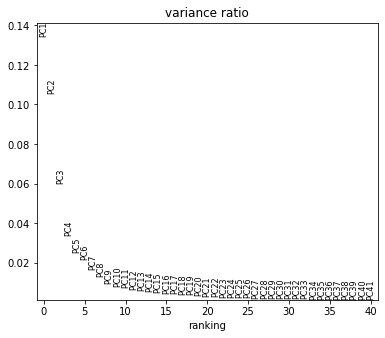

In [80]:
sc.pp.pca(adata, n_comps = 50, use_highly_variable = True)
sc.pl.pca_variance_ratio(adata, n_pcs = 40)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:09:50)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 35 clusters and added
    'louvain_1', the cluster labels (adata.obs, categorical) (0:07:40)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 49 clusters and added
    'louvain_2', the cluster labels (adata.obs, categorical) (0:09:56)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:20:16)


... storing 'phase' as categorical


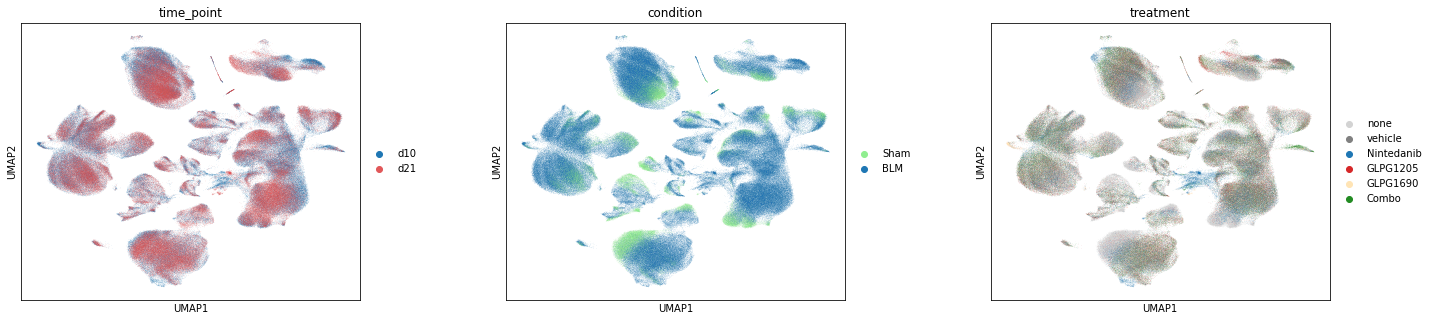

In [81]:
sc.pp.neighbors(adata, n_pcs = 50, n_neighbors = 30)  ## this one took two hours on hias
sc.tl.louvain(adata, resolution = 1, key_added = "louvain_1")
sc.tl.louvain(adata, resolution = 2, key_added = "louvain_2")

sc.tl.umap(adata)
sc.pl.umap(adata, color = ["time_point", "condition", "treatment"], wspace = 0.3)

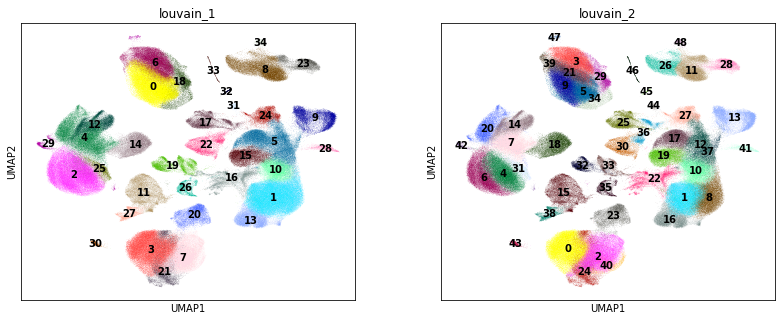

In [87]:
sc.pl.umap(adata, color = ["louvain_1", "louvain_2"], legend_loc = "on data")

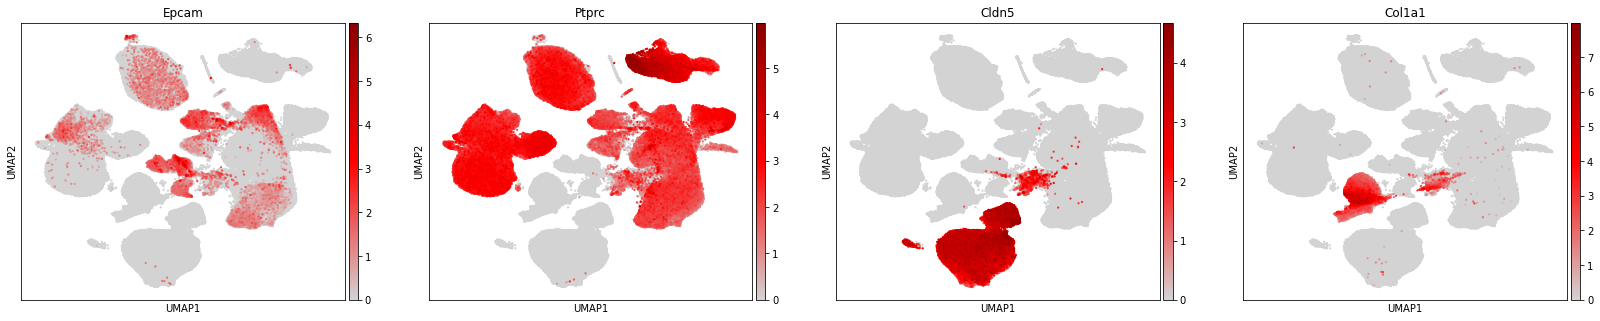

In [85]:
sc.pl.umap(adata, color = ["Epcam", "Ptprc", "Cldn5", "Col1a1"], size = 20, cmap = gray_red)

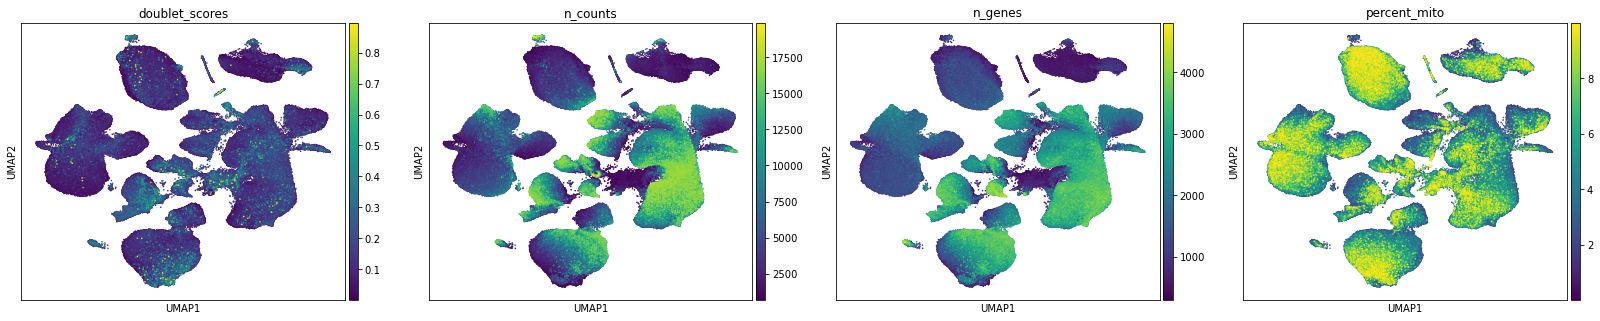

In [84]:
sc.pl.umap(adata, color = ["doublet_scores", "n_counts", "n_genes", "percent_mito"], size = 10)

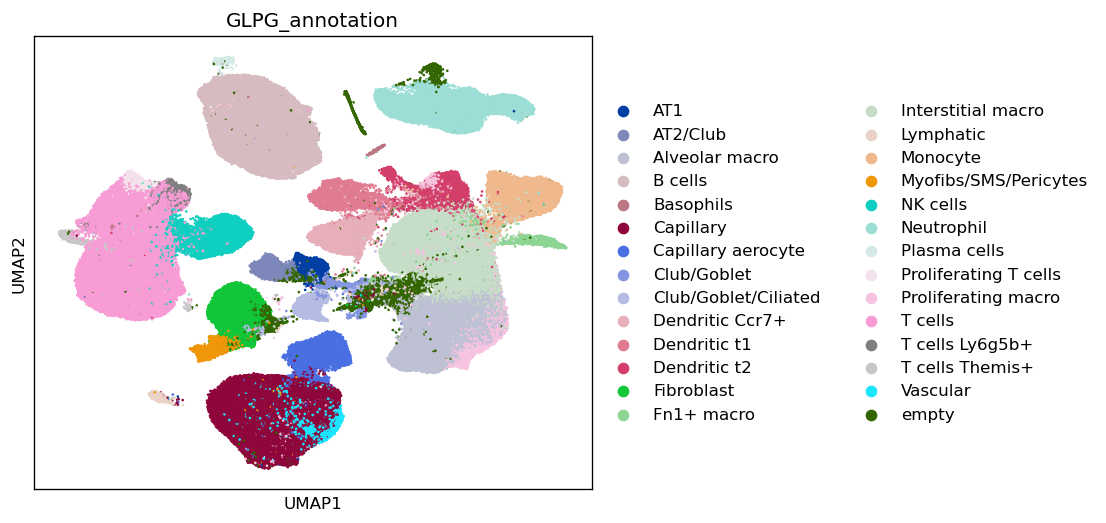

In [83]:
sc.pl.umap(adata, color = ["GLPG_annotation"], size = 10, ax = mysize(6, 5, 120))

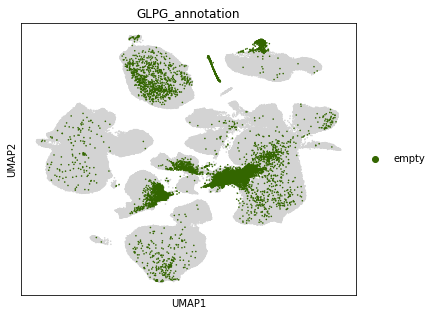

In [92]:
sc.pl.umap(adata, color = ["GLPG_annotation"], groups = ["empty"], size = 10)

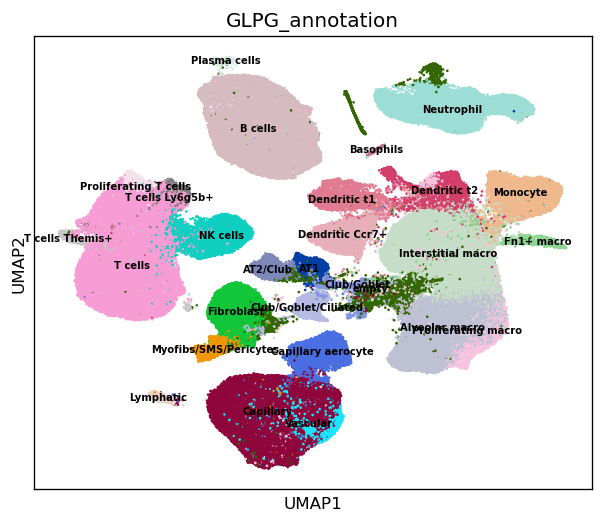

In [90]:
sc.pl.umap(adata, color = ["GLPG_annotation"], legend_loc = "on data",
           legend_fontsize = 6, size = 10, ax = mysize(6, 5, 120))

In [93]:
## Save this object
folder = "/storage/groups/ml01/workspace/meshal.ansari/PhD_Scripts/GLPG/"
adata.write(folder + "210129_GLPG_souped_filtered.h5ad")

### Some more Plots

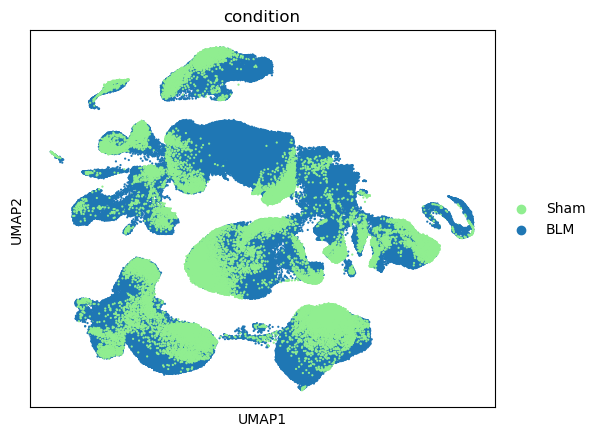

In [3]:
folder = "/storage/groups/ml01/workspace/meshal.ansari/PhD_Scripts/GLPG/"

adata = sc.read(folder + "210119_GLPG_souped.h5ad")
sc.pl.umap(adata, color = ["condition"], size = 10, ax = mysize(6, 5, 100))

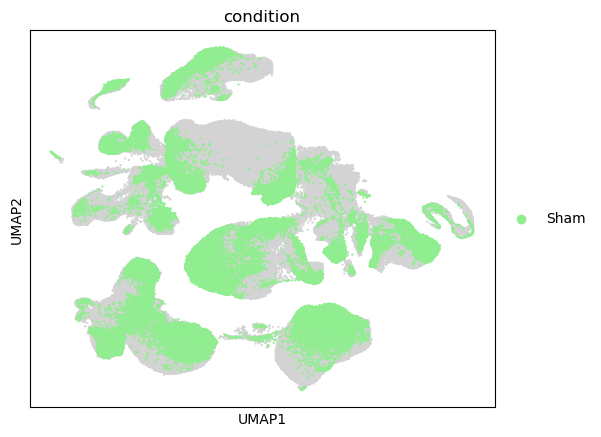

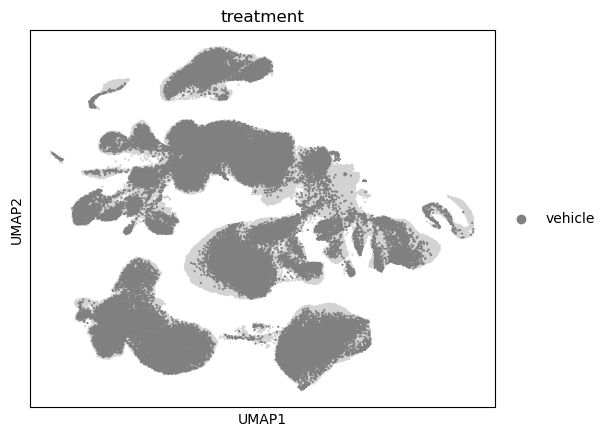

In [ ]:
for t in adata.obs.treatment.cat.categories:
    if t == "none":
        sc.pl.umap(adata, color = ["condition"], size = 10, ax = mysize(6, 5, 100), groups = ["Sham"])  
    else:
        sc.pl.umap(adata, color = ["treatment"], size = 10, ax = mysize(6, 5, 100), groups = [t])    